# AES-T600 data set

## Import libraries

In [2]:
# %reset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField
import cv2


In [3]:
# function for resize image
def resize_dataset(dataset, new_size=(128, 128)):
    num_samples = dataset.shape[0]
    resized_dataset = np.zeros((num_samples, 1, new_size[0], new_size[1]))

    for i in range(num_samples):
        # Reshape to 2D, resize and then reshape back to 4D , interpolation=cv2.INTER_AREA
        image = dataset[i, 0, :, :]
        resized_image = cv2.resize(image, new_size)
        resized_dataset[i, 0, :, :] = resized_image

    return resized_dataset

In [4]:
model = nn.Sequential(
          nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=2),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2, stride=2),
          nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size=2, stride=2),
          nn.Flatten(),
          nn.LazyLinear(100),  # Adjust the size
          nn.ReLU(),
          nn.Linear(100, 2)
        )

d:\anaconda3\envs\QU_AIoT\Lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [7]:
model.load_state_dict(torch.load('model_T500.pth'))

<All keys matched successfully>

## Prameters

In [5]:
sample_numbers = 10000
data_name ='T500'
im_size=50


## Paths

In [6]:
base_path=f"D:\AIoT_project\data_sets\IEEE_dataPort\AES-{data_name}_power_Temp25C\AES-{data_name}_power_Temp25C"
trj_disabled= f"\AES-{data_name}+TrojanDisabled_1\AES-{data_name}+TrojanDisabled_1"
trj_enabled= f"\AES-{data_name}+TrojanTriggered_1\AES-{data_name}+TrojanTriggered_1"

## Load and prepare data

In [7]:
data_folder = Path(base_path + trj_disabled)
# Initialize a list to hold all arrays
labeled_arrays = []
# Loop through file indices
for i in range(sample_numbers):  # 500 because range is exclusive of the upper bound
    file_path = data_folder / f"Sample_{i}.csv"
    
    # Read the file
    data = pd.read_csv(file_path, header=None)
    
    # Convert the column to a NumPy array
    array = data[0].to_numpy()

    # Create a labeled array (features + label)
    labeled_array = np.append(array, 0)  # Appending label '0' for disabled

    # Append the labeled array to the list
    labeled_arrays.append(labeled_array)

# Convert the list of labeled arrays into a 2D NumPy array (matrix)
trj_data_disb = np.array(labeled_arrays)


data_folder = Path(base_path + trj_enabled)
# Initialize a list to hold all arrays
labeled_arrays = []
# Loop through file indices
for i in range(sample_numbers):  # 500 because range is exclusive of the upper bound
    file_path = data_folder / f"Sample_{i}.csv"
    
    # Read the file
    data = pd.read_csv(file_path, header=None)
    
    # Convert the column to a NumPy array
    array = data[0].to_numpy()

    # Create a labeled array (features + label)
    labeled_array = np.append(array, 1)  # Appending label '1' for disabled

    # Append the labeled array to the list
    labeled_arrays.append(labeled_array)


# Convert the list of arrays into a 2D NumPy array (matrix)
trj_data_trig = np.array(labeled_arrays)

# Concatenate trj_data_disb and trj_data_trig row-wise
trj_data = np.concatenate((trj_data_disb, trj_data_trig), axis=0)
np.random.shuffle(trj_data)


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(trj_data[:, :-1], trj_data[:, -1], test_size=0.2)  # 20% for validation



X_train_img = X_train.reshape(-1, 1, 50, 50)
X_val_img = X_val.reshape(-1, 1, 50, 50)

X_train_cnn = resize_dataset(X_train_img,new_size=[im_size, im_size])
X_val_cnn = resize_dataset(X_val_img,new_size=[im_size, im_size])


mean = X_train_cnn.mean()
std = X_train_cnn.std()

# Normalize the datasets
X_train_cnn = (X_train_cnn - mean) / std
X_val_cnn = (X_val_cnn - mean) / std


tf_gs=GramianAngularField(image_size=im_size,method='summation')
X_train_gs=tf_gs.fit_transform(X_train)
X_val_gs=tf_gs.transform(X_val)


X_train_gs = X_train_gs.reshape(-1, 1, im_size, im_size)
X_val_gs = X_val_gs.reshape(-1, 1, im_size, im_size)


# X_train = np.transpose(X_train, (0,1,3,2))
# X_val = np.transpose(X_val, (0,1,3,2))

X_train_2d = np.concatenate((X_train_cnn, X_train_gs), axis=1)
X_val_2d = np.concatenate((X_val_cnn, X_val_gs), axis=1)


In [ ]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Assuming resize_dataset, tf_gs, model, criterion are already defined and initialized
# Also assuming X_val, y_val, mean, std, and im_size are predefined
results = []
val_accuracies = []
val_losses = []
noise_levels = np.arange(0, 5.5, .5)  # From 1 to 10

for noise_std_dev in noise_levels:
    # Generate Gaussian noise
    noise = np.random.normal(0, noise_std_dev, X_val.shape)

    # Add the noise to the validation data
    X_val_noise = X_val + noise
    X_val_noise_img = X_val_noise.reshape(-1, 1, 50, 50)

    X_val_noise_cnn = resize_dataset(X_val_noise_img, new_size=[im_size, im_size])
    X_val_noise_cnn = (X_val_noise_cnn - mean) / std

    X_val_noise_gs = tf_gs.fit_transform(X_val_noise.reshape(-1, 50*50))
    X_val_noise_gs = X_val_noise_gs.reshape(-1, 1, im_size, im_size)

    X_val_noise_2d = np.concatenate((X_val_noise_cnn, X_val_noise_gs), axis=1)

    X_val_t = torch.tensor(X_val_noise_2d, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    val_dataset = TensorDataset(X_val_t, y_val_t)
    val_loader = DataLoader(val_dataset, batch_size=32)

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)
    results.append({'noise_std_dev': noise_std_dev, 'val_loss': val_loss, 'val_accuracy': accuracy})



In [ ]:
X_train, X_val, y_train, y_val = train_test_split(trj_data[:, :-1], trj_data[:, -1], test_size=0.2)  # 20% for validation



X_train_img = X_train.reshape(-1, 1, 50, 50)
X_val_img = X_val.reshape(-1, 1, 50, 50)

X_train_cnn = resize_dataset(X_train_img,new_size=[im_size, im_size])
X_val_cnn = resize_dataset(X_val_img,new_size=[im_size, im_size])


mean = X_train_cnn.mean()
std = X_train_cnn.std()

# Normalize the datasets
X_train_cnn = (X_train_cnn - mean) / std
X_val_cnn = (X_val_cnn - mean) / std


tf_gs=GramianAngularField(image_size=im_size,method='summation')
X_train_gs=tf_gs.fit_transform(X_train)
X_val_gs=tf_gs.fit_transform(X_val)


X_train_gs = X_train_gs.reshape(-1, 1, im_size, im_size)
X_val_gs = X_val_gs.reshape(-1, 1, im_size, im_size)


# X_train = np.transpose(X_train, (0,1,3,2))
# X_val = np.transpose(X_val, (0,1,3,2))

X_train_2d = np.concatenate((X_train_cnn, X_train_gs), axis=1)
X_val_2d = np.concatenate((X_val_cnn, X_val_gs), axis=1)


In [152]:
sample=1

sample_no_HT = trj_data_disb[sample,:-1]
sample_HT = trj_data_trig[sample,:-1]

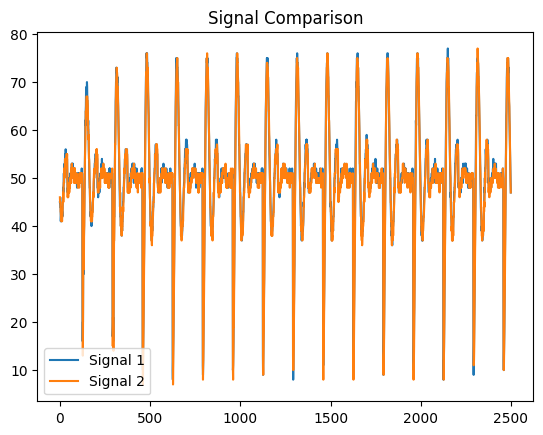

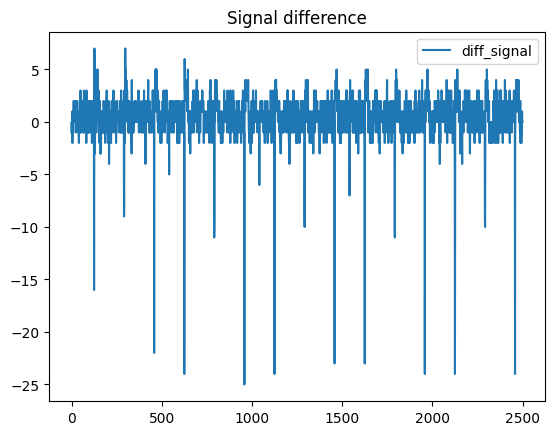

Mean of Signal 1: 50.2, Mean of Signal 2: 49.7388
Standard Deviation of Signal 1: 10.731411836286966, Standard Deviation of Signal 2: 10.747733461525737
Pearson Correlation Coefficient: 0.9796276433717905


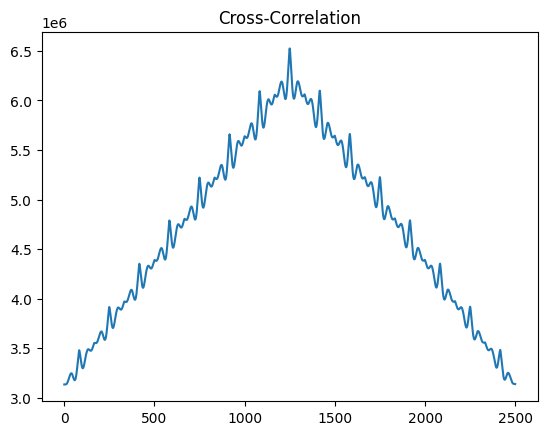

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
from scipy.signal import correlate
from scipy.fft import fft

# Example signals
signal1 = sample_no_HT
signal2 = sample_HT
diff_signal = signal1- signal2


# Visual Inspection
plt.plot(signal1, label='Signal 1')
plt.plot(signal2, label='Signal 2')
plt.legend()
plt.title('Signal Comparison')
plt.show()


plt.plot(diff_signal, label='diff_signal')
plt.legend()
plt.title('Signal difference')
plt.show()

# Statistical Measures
mean1, mean2 = np.mean(signal1), np.mean(signal2)
std1, std2 = np.std(signal1), np.std(signal2)
print(f'Mean of Signal 1: {mean1}, Mean of Signal 2: {mean2}')
print(f'Standard Deviation of Signal 1: {std1}, Standard Deviation of Signal 2: {std2}')

# Correlation Coefficient
corr_coeff, _ = pearsonr(signal1, signal2)
print(f'Pearson Correlation Coefficient: {corr_coeff}')

# Cross-Correlation
cross_corr = correlate(signal1, signal2, mode='same')
plt.plot(cross_corr)
plt.title('Cross-Correlation')
plt.show()

# Dynamic Time Warping
# distance, path = fastdtw(signal1, signal2, dist=euclidean)
# print(f'DTW Distance: {distance}')

# Frequency Analysis
# fft_signal1 = fft(signal1)
# fft_signal2 = fft(signal2)
# plt.plot(np.abs(fft_signal1), label='FFT Signal 1')
# plt.plot(np.abs(fft_signal2), label='FFT Signal 2')
# plt.legend()
# plt.title('Frequency Analysis')
# plt.show()


In [154]:
import numpy as np
import tsfel
import pandas as pd


# Load TSFEL configuration
cfg = tsfel.get_features_by_domain()

# Extract features from signals
features_signal1 = tsfel.time_series_features_extractor(cfg, signal1)
features_signal2 = tsfel.time_series_features_extractor(cfg, signal2)

# print("feature signal1: ",features_signal1)

# Convert to DataFrame for easier comparison
df_features_signal1 = pd.DataFrame(features_signal1)
df_features_signal2 = pd.DataFrame(features_signal2)

# Compare features (example: correlation between corresponding features)
feature_correlations = df_features_signal1.corrwith(df_features_signal2, axis=0)
# print(feature_correlations)

print("feature signal: ",df_features_signal1)




*** Feature extraction started ***


C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\3754921584.py:10: UserWarning: Using default sampling frequency set in configuration file.
  features_signal1 = tsfel.time_series_features_extractor(cfg, signal1)



*** Feature extraction finished ***
*** Feature extraction started ***


C:\Users\Admin\AppData\Local\Temp\ipykernel_6600\3754921584.py:11: UserWarning: Using default sampling frequency set in configuration file.
  features_signal2 = tsfel.time_series_features_extractor(cfg, signal2)



*** Feature extraction finished ***
feature signal:     0_Absolute energy  0_Area under the curve  0_Autocorrelation  \
0          6588008.0                 1254.54          6588008.0   

   0_Average power  0_Centroid  0_ECDF Percentile Count_0  \
0    263625.770308   12.590063                      500.0   

   0_ECDF Percentile Count_1  0_ECDF Percentile_0  0_ECDF Percentile_1  \
0                     2000.0                 47.0                 55.0   

   0_ECDF_0  ...  0_Wavelet variance_0  0_Wavelet variance_1  \
0    0.0004  ...              7.529256             39.284753   

   0_Wavelet variance_2  0_Wavelet variance_3  0_Wavelet variance_4  \
0            112.668251             248.42104            461.140682   

   0_Wavelet variance_5  0_Wavelet variance_6  0_Wavelet variance_7  \
0            749.346344           1092.365744           1454.566792   

   0_Wavelet variance_8  0_Zero crossing rate  
0           1794.187111                   0.0  

[1 rows x 389 columns]


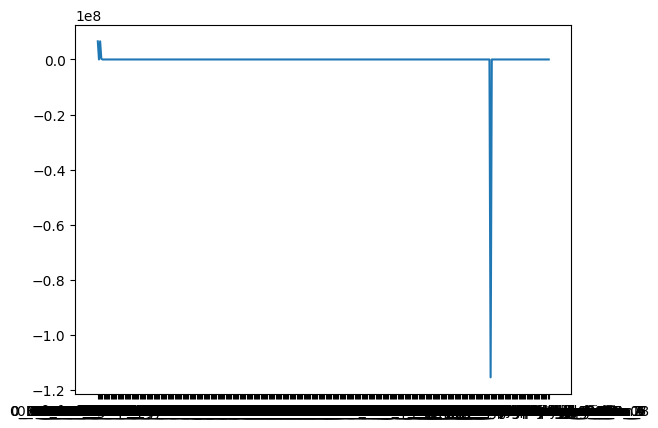

In [155]:
plt.plot(features_signal1.iloc[0])

In [156]:
import numpy as np

difference_signal = np.array(signal1) - np.array(signal2)


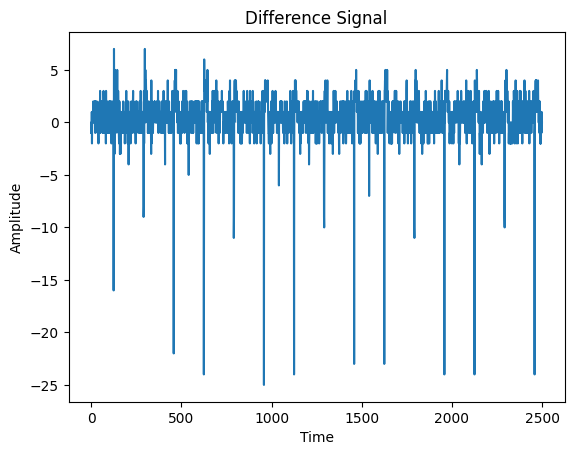

In [157]:
import matplotlib.pyplot as plt

plt.plot(difference_signal)
plt.title('Difference Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

Mean: 0.4612, Standard Deviation: 2.1678778932403


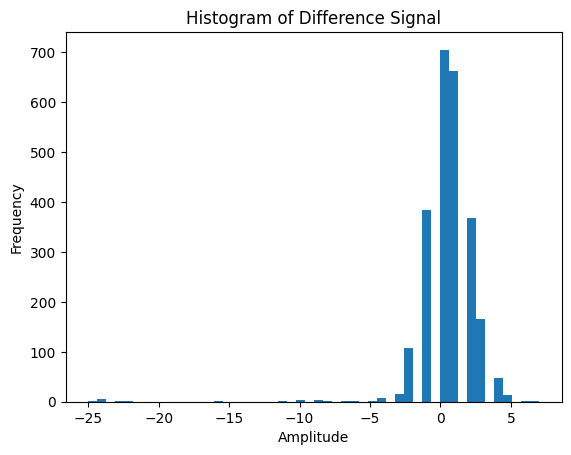

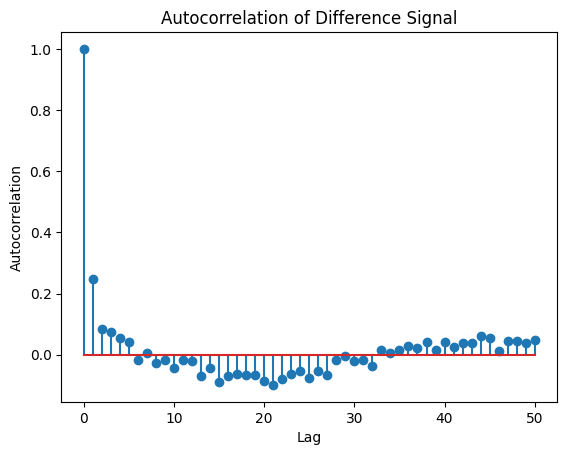

In [158]:
mean = np.mean(difference_signal)
std_dev = np.std(difference_signal)
print(f'Mean: {mean}, Standard Deviation: {std_dev}')

# Histogram
plt.hist(difference_signal, bins=50)
plt.title('Histogram of Difference Signal')
plt.xlabel('Amplitude')
plt.ylabel('Frequency')
plt.show()

# Autocorrelation
from statsmodels.tsa.stattools import acf

autocorr = acf(difference_signal, fft=True, nlags=50)
plt.stem(autocorr)
plt.title('Autocorrelation of Difference Signal')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()


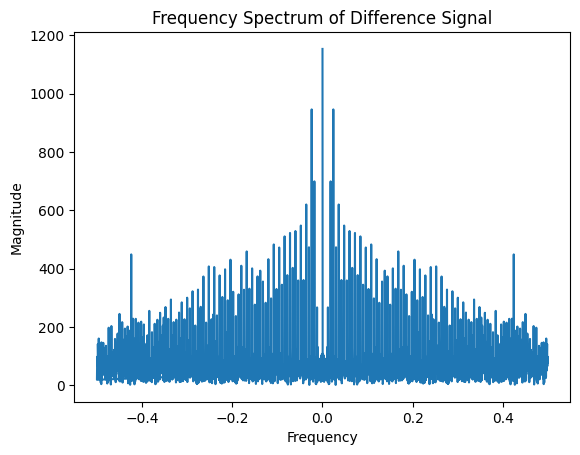

In [159]:
from scipy.fft import fft

# Compute the Fourier Transform
fft_result = fft(difference_signal)
fft_magnitude = np.abs(fft_result)

# Frequency axis
freqs = np.fft.fftfreq(len(difference_signal), d=1.0)  # Assuming sampling rate is 1

plt.plot(freqs, fft_magnitude)
plt.title('Frequency Spectrum of Difference Signal')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()


In [160]:
! pip install statsmodels